# VAE (Vanilla) — Anomaly Detection
Baseline VAE for reconstruction-based anomaly scoring.

In [ ]:
# ====== Imports ======
from __future__ import annotations
import os, json, math
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from PIL import Image

import torchvision
import torchvision.transforms as T
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
import numpy as np

try:
    from sklearn.metrics import roc_auc_score, roc_curve
    SKLEARN_OK = True
except ImportError:
    print("scikit-learn not found. Run: pip install scikit-learn")
    SKLEARN_OK = False

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.2.1+cu121
cuda available: True


## 0) Configuration
Set data paths, model size, and training/inference hyperparameters here.

In [ ]:
# ====== Config ======
CFG = {
    
    "train_dir": "./train2",
    "test_dir":  "./test4",
   
    "img_size":  256,
    "channels":  1,
    "normalize": True,
  
    "batch_size":  32,
    "num_workers": 2,
  
    "out_dir":    "./runs/vae_marble",
    "save_every": 5,
  
    "base_channels": 64,
    "latent_dim":    128,   # latent vector dim
    "dropout":       0.1,

    "epochs":       80,
    "lr":           1e-4,
    "weight_decay": 1e-4,
    "kld_weight":   0.001,  # KL divergence weight

    # ── Inference ───────────────────────────────────────────────────
    "aggregate": "topk",
    "topk":      0.05,
}

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out_dir = Path(CFG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)
(out_dir/"hparams.json").write_text(json.dumps(CFG, indent=2), encoding="utf-8")
print("device:", device)
print("out_dir:", out_dir.resolve())

device: cuda
out_dir: /home/yuw307/vqvae pipeline/runs/vae_marble


## 1) Dataset and DataLoader
Supports ImageFolder layout or flat-folder layout.

In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}

class FlatFolderDataset(torch.utils.data.Dataset):
    
    def __init__(self, data_dir: str, transform=None):
        self.data_dir  = Path(data_dir)
        self.transform = transform
        self.filepaths = sorted([
            p for p in self.data_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMG_EXTS
        ])
        if len(self.filepaths) == 0:
            raise FileNotFoundError(
                f"No images found in {data_dir}\n"
                f"Supported: {IMG_EXTS}\n"
                f"Make sure images are directly in the folder, not in subfolders."
            )
        class_name          = self.data_dir.name
        self.classes        = [class_name]
        self.class_to_idx   = {class_name: 0}
        self.targets        = [0] * len(self.filepaths)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0


def build_transform(img_size: int, channels: int, augment: bool = False) -> T.Compose:
    """
    augment=True  → for training
    augment=False → for stats / testing
    """
    tfms = []
    if channels == 1:
        tfms.append(T.Grayscale(num_output_channels=1))

    if augment:
        crop_size = int(img_size * 1.15)
        tfms += [
            T.Resize((crop_size, crop_size)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomApply([T.RandomRotation(degrees=(90, 90))], p=0.5),
            T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15)], p=0.5),
        ]
    else:
        tfms.append(T.Resize((img_size, img_size)))

    tfms.append(T.ToTensor())

    if CFG.get("normalize", False):
        mean = [0.5] * channels
        std  = [0.5] * channels
        tfms.append(T.Normalize(mean=mean, std=std))  # → [-1, 1]

    return T.Compose(tfms)


def make_loader(data_dir: str, shuffle: bool):
    """
    shuffle=True  → augment=True  （for training）
    shuffle=False → augment=False （for stats / test）
    """
    transform = build_transform(CFG["img_size"], CFG["channels"], augment=shuffle)
    root      = Path(data_dir)

    
    valid_subdirs = [p for p in root.iterdir() if p.is_dir() and not p.name.startswith('.')]
    has_subdir = len(valid_subdirs) > 0
    if has_subdir:
        
        import torchvision.datasets as tvd
        class FilteredImageFolder(tvd.ImageFolder):
            def find_classes(self, directory):
                classes = [d.name for d in Path(directory).iterdir()
                           if d.is_dir() and not d.name.startswith('.')]
                classes.sort()
                
                priority = {}
                for c in classes:
                    if 'good' in c.lower():   priority[c] = 0
                    elif 'defect' in c.lower() or 'bad' in c.lower() or 'ng' in c.lower(): priority[c] = 1
                    else: priority[c] = 2 + classes.index(c)
                classes = sorted(classes, key=lambda c: priority[c])
                class_to_idx = {c: i for i, c in enumerate(classes)}
                return classes, class_to_idx
        ds = FilteredImageFolder(root=data_dir, transform=transform)
    else:
        ds = FlatFolderDataset(data_dir=data_dir, transform=transform)

    loader = DataLoader(
        ds,
        batch_size=CFG["batch_size"],
        shuffle=shuffle,
        num_workers=CFG["num_workers"],
        pin_memory=True,
        drop_last=False,
    )
    return loader, ds.class_to_idx, ds



train_loader, train_label_map, train_ds = make_loader(CFG["train_dir"], shuffle=True)
test_loader,  test_label_map,  test_ds  = make_loader(CFG["test_dir"],  shuffle=False)

(out_dir / "train_label_map.txt").write_text(
    "\n".join(f"{k}\t{v}" for k,v in train_label_map.items()), encoding="utf-8")
(out_dir / "test_label_map.txt").write_text(
    "\n".join(f"{k}\t{v}" for k,v in test_label_map.items()),  encoding="utf-8")

print(f"train classes: {train_ds.classes}  |  train samples: {len(train_ds)}")
print(f"test  classes: {test_ds.classes}   |  test  samples: {len(test_ds)}")
print(f"train batches: {len(train_loader)} |  test  batches: {len(test_loader)}")

train classes: ['train2']  |  train samples: 1523
test  classes: ['good', 'defect']   |  test  samples: 545
train batches: 48 |  test  batches: 18


### 1.1 Preview a Training Batch
Sanity check the input size and normalization.

batch shape: torch.Size([32, 1, 256, 256]) | labels: [0, 0, 0, 0, 0, 0, 0, 0]


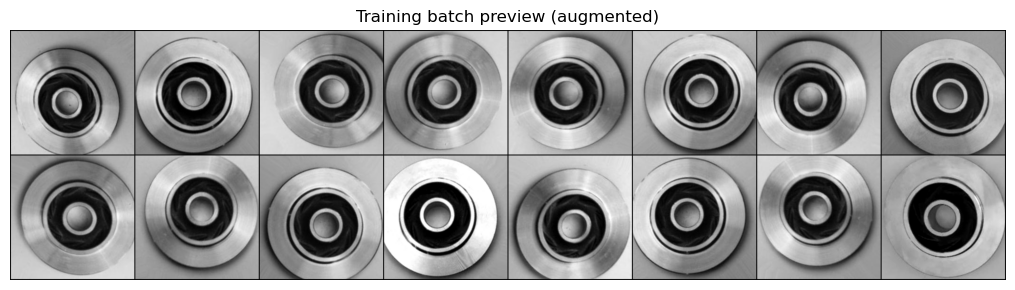

In [4]:
x0, y0 = next(iter(train_loader))
print("batch shape:", x0.shape, "| labels:", y0[:8].tolist())
grid = make_grid(x0[:16], nrow=8, normalize=True)
save_image(grid, str(out_dir / "train_batch_preview.png"))

plt.figure(figsize=(12,3))
plt.imshow(grid.permute(1,2,0).cpu(), cmap="gray" if CFG["channels"]==1 else None)
plt.axis("off")
plt.title("Training batch preview (augmented)")
plt.tight_layout()
plt.show()

## 2) VAE Model
CNN encoder/decoder with a latent Gaussian bottleneck.

In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, in_channels: int, base_channels: int,
                 latent_dim: int, dropout: float = 0.0):
        super().__init__()
        c = base_channels
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, c, 4, 2, 1),
            nn.BatchNorm2d(c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(c, 2*c, 4, 2, 1),
            nn.BatchNorm2d(2*c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.Conv2d(2*c, 4*c, 4, 2, 1),
            nn.BatchNorm2d(4*c), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(4*c, 4*c, 3, 1, 1),
            nn.BatchNorm2d(4*c), nn.LeakyReLU(0.2, inplace=True),
        )
        
        self.feat_h = None
        flat_dim_placeholder = 4 * c  

       
        dummy = torch.zeros(1, in_channels,
                            CFG["img_size"], CFG["img_size"])
        feat  = self.net(dummy)
        self.feat_shape = feat.shape[1:]  # (C, H, W)
        flat_dim = int(feat.numel())

        self.fc_mu     = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h    = self.net(x).flatten(1)
        mu   = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class VAEDecoder(nn.Module):
    def __init__(self, out_channels: int, base_channels: int,
                 latent_dim: int, feat_shape: tuple, dropout: float = 0.0):
        super().__init__()
        c = base_channels
        flat_dim = int(feat_shape[0] * feat_shape[1] * feat_shape[2])
        self.feat_shape = feat_shape
        self.fc = nn.Linear(latent_dim, flat_dim)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(4*c, 4*c, 3, 1, 1),
            nn.BatchNorm2d(4*c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.ConvTranspose2d(4*c, 2*c, 4, 2, 1),
            nn.BatchNorm2d(2*c), nn.LeakyReLU(0.2, inplace=True), nn.Dropout2d(dropout),
            nn.ConvTranspose2d(2*c, c, 4, 2, 1),
            nn.BatchNorm2d(c), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(c, out_channels, 4, 2, 1),
           
        )

    def forward(self, z):
        h = self.fc(z).view(-1, *self.feat_shape)
        return self.net(h)


class VAE(nn.Module):
    def __init__(self, img_size=256, in_channels=1, base_channels=64,
                 latent_dim=128, dropout=0.0):
        super().__init__()
        self.img_size    = img_size
        self.in_channels = in_channels
        self.latent_dim  = latent_dim
        self.encoder = VAEEncoder(in_channels, base_channels, latent_dim, dropout)
        self.decoder = VAEDecoder(in_channels, base_channels, latent_dim,
                                  self.encoder.feat_shape, dropout)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decoder(z)
        return x_hat, mu, logvar

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return self.reparameterize(mu, logvar)

    def decode(self, z):
        return self.decoder(z)


model = VAE(
    img_size      = CFG["img_size"],
    in_channels   = CFG["channels"],
    base_channels = CFG["base_channels"],
    latent_dim    = CFG["latent_dim"],
    dropout       = CFG.get("dropout", 0.1),
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"VAE ready | params: {total_params:,}")
print(f"Latent dim: {CFG['latent_dim']}")

VAE ready | params: 103,421,569
Latent dim: 128


## 3) Train the VAE
Optimizes reconstruction loss + KL divergence.

In [ ]:
def vae_loss(x_hat, x, mu, logvar, kld_weight=0.001):
    """
    ELBO loss = Recon loss + β * KLD
    KLD = -0.5 * sum(1 + logvar - mu² - exp(logvar))
    """
    recon = F.mse_loss(x_hat, x, reduction="mean")
    kld   = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + kld_weight * kld
    return total, recon, kld


opt       = torch.optim.Adam(model.parameters(),
                              lr=CFG["lr"], weight_decay=CFG.get("weight_decay", 1e-4))
loss_hist = {"total":[], "recon":[], "kld":[]}

for epoch in range(1, CFG["epochs"]+1):
    model.train()
    tot = rec = kldv = nb = 0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)
        x_hat, mu, logvar = model(x)
        loss, recon, kld  = vae_loss(x_hat, x, mu, logvar, CFG["kld_weight"])

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        tot  += float(loss);  rec += float(recon)
        kldv += float(kld);   nb  += 1

    tot_m = tot/max(nb,1); rec_m = rec/max(nb,1); kld_m = kldv/max(nb,1)
    print(f"Epoch {epoch:03d} | loss={tot_m:.6f} | recon={rec_m:.6f} | kld={kld_m:.6f}")
    loss_hist["total"].append(tot_m)
    loss_hist["recon"].append(rec_m)
    loss_hist["kld"].append(kld_m)
    (out_dir/"loss_history.json").write_text(json.dumps(loss_hist, indent=2), encoding="utf-8")

    if epoch % CFG["save_every"] == 0:
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "opt_state":   opt.state_dict(),
            "cfg":         CFG,
        }, out_dir/"last.pt")

print("Training done. Checkpoint:", out_dir/"last.pt")

Epoch 001 | loss=1.667317 | recon=1.427332 | kld=239.984229
Epoch 002 | loss=0.417892 | recon=0.399237 | kld=18.654575
Epoch 003 | loss=0.247690 | recon=0.234192 | kld=13.498246
Epoch 004 | loss=0.172490 | recon=0.156332 | kld=16.157746
Epoch 005 | loss=0.140181 | recon=0.126129 | kld=14.052154
Epoch 006 | loss=0.133390 | recon=0.113812 | kld=19.578022
Epoch 007 | loss=0.119434 | recon=0.102499 | kld=16.934275
Epoch 008 | loss=0.108909 | recon=0.091990 | kld=16.919399
Epoch 009 | loss=0.100887 | recon=0.084545 | kld=16.341797
Epoch 010 | loss=0.099895 | recon=0.081872 | kld=18.022686
Epoch 011 | loss=0.094386 | recon=0.076964 | kld=17.422044
Epoch 012 | loss=0.095413 | recon=0.077500 | kld=17.912925
Epoch 013 | loss=0.091273 | recon=0.074403 | kld=16.869742
Epoch 014 | loss=0.085279 | recon=0.069241 | kld=16.037707
Epoch 015 | loss=0.083792 | recon=0.068096 | kld=15.695788
Epoch 016 | loss=0.080663 | recon=0.064614 | kld=16.048798
Epoch 017 | loss=0.079380 | recon=0.063440 | kld=15.939

### 3.1 Training Curves
Loss trends over epochs.

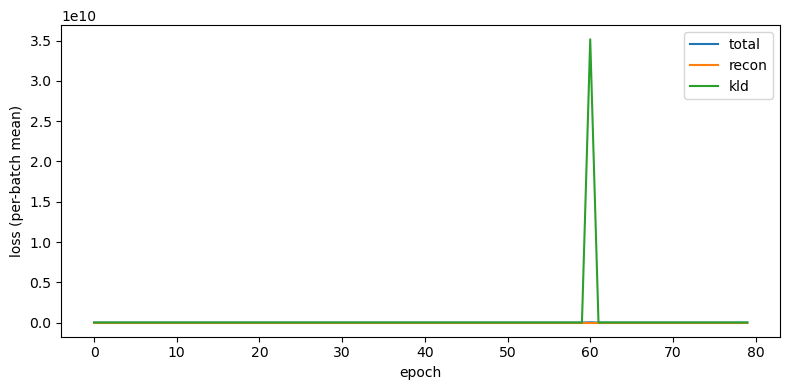

In [7]:
plt.figure(figsize=(8,4))
plt.plot(loss_hist["total"], label="total")
plt.plot(loss_hist["recon"], label="recon")
plt.plot(loss_hist["kld"],   label="kld")
plt.xlabel("epoch"); plt.ylabel("loss (per-batch mean)")
plt.legend(); plt.tight_layout(); plt.show()

## 4) Inference — Anomaly Scoring
Compute anomaly scores from pixel-wise reconstruction error.

In [ ]:
@torch.no_grad()
def infer_scores_vae(model, loader, device):
    
    model.eval()
    results = []

    for bi, (x, y) in enumerate(loader):
        x     = x.to(device, non_blocking=True)
        x_hat, mu, logvar = model(x)

        if CFG.get("normalize", False):
            x_vis     = x     * 0.5 + 0.5
            x_hat_vis = x_hat * 0.5 + 0.5
        else:
            x_vis, x_hat_vis = x, x_hat

        # pixel-wise MSE map
        err_map = (x_vis - x_hat_vis).pow(2)  # [B, C, H, W]
        flat    = err_map.view(x.size(0), -1).cpu()

        # aggregate
        mode = CFG["aggregate"]
        if mode == "max":
            img_scores = flat.max(1).values
        elif mode == "mean":
            img_scores = flat.mean(1)
        elif mode == "topk":
            k = max(int(CFG["topk"] * flat.size(1)), 1)
            img_scores = torch.topk(flat, k, dim=1).values.mean(1)

        for b in range(x.size(0)):
            results.append({
                "index": bi * CFG["batch_size"] + b,
                "label": int(y[b].item()),
                "score": float(img_scores[b].item()),
            })
    return results


infer_results = infer_scores_vae(model, test_loader, device)
(out_dir/"infer_scores.json").write_text(json.dumps(infer_results, indent=2), encoding="utf-8")
print(f"Scored {len(infer_results)} test images")

✅ Scored 545 test images


### 4.1 Score Distribution, AUROC, and Top Anomalies
Visualize score separation between normal and defect samples.

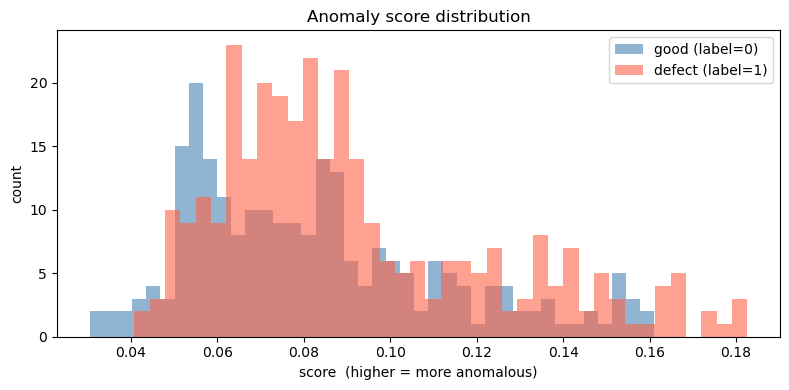

Score stats — min: 0.03  max: 0.18  mean: 0.09  std: 0.03
Good   scores — mean: 0.08  std: 0.03
Defect scores — mean: 0.09  std: 0.03

  AUROC = 0.5815  (58.1%)
  0.5 = random guess  |  1.0 = perfect detection


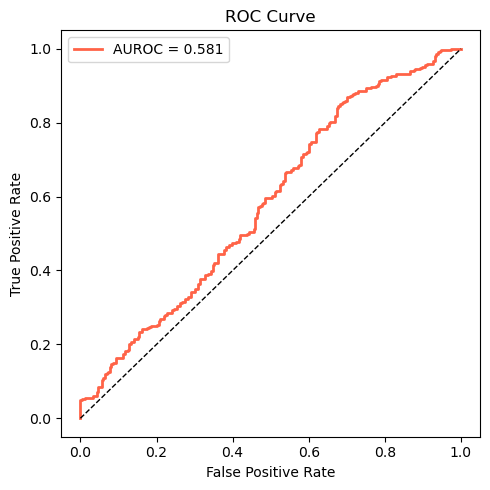


Best threshold (Youden's J): 0.061
  TP=271  FP=163  TN=70  FN=41
  Precision=0.624  Recall=0.869

Top anomaly indices: [284, 21, 41, 47, 38, 244, 273, 57]
Top anomaly scores : [0.18, 0.18, 0.18, 0.18, 0.17, 0.17, 0.17, 0.17]


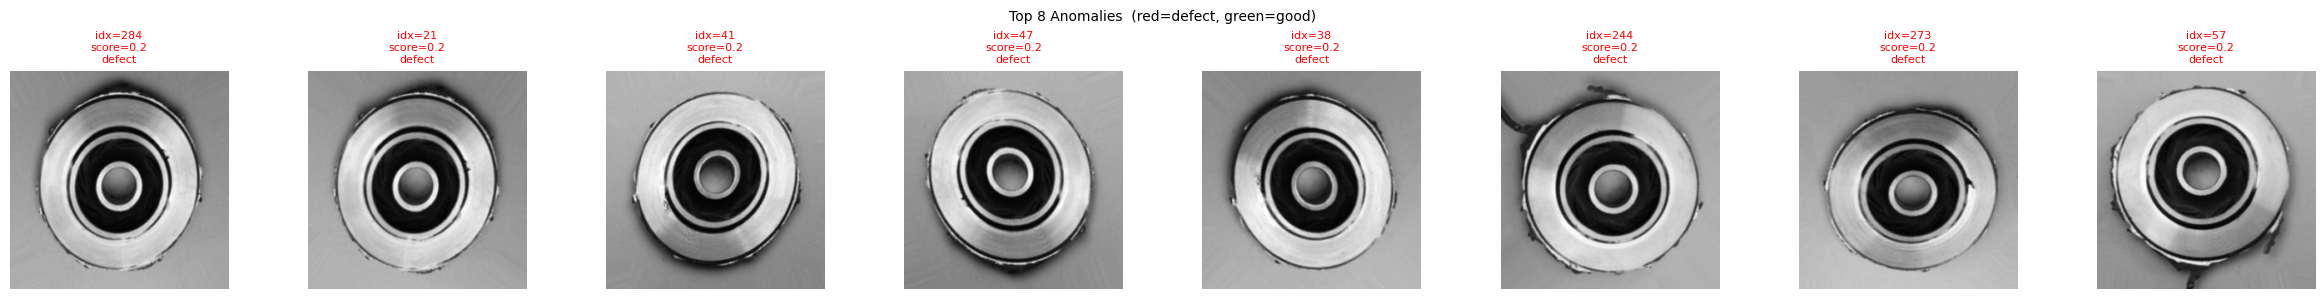

In [ ]:
scores = torch.tensor([r["score"] for r in infer_results])
labels = torch.tensor([r["label"] for r in infer_results])

# ── Score distribution ───────────────────────────────────────────────
plt.figure(figsize=(8,4))
has_defect = (labels == 1).any().item()
if has_defect:
    plt.hist(scores[labels==0].numpy(), bins=40, alpha=0.6, label="good (label=0)",    color="steelblue")
    plt.hist(scores[labels==1].numpy(), bins=40, alpha=0.6, label="defect (label=1)",  color="tomato")
    plt.legend()
else:
    plt.hist(scores.numpy(), bins=50, color="steelblue")
plt.title("Anomaly score distribution")
plt.xlabel("score  (higher = more anomalous)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print(f"Score stats — min: {scores.min():.2f}  max: {scores.max():.2f}  "
      f"mean: {scores.mean():.2f}  std: {scores.std():.2f}")
if has_defect:
    good_scores   = scores[labels==0]
    defect_scores = scores[labels==1]
    print(f"Good   scores — mean: {good_scores.mean():.2f}  std: {good_scores.std():.2f}")
    print(f"Defect scores — mean: {defect_scores.mean():.2f}  std: {defect_scores.std():.2f}")

# ── AUROC ────────────────────────────────────────────────────────────
if has_defect and SKLEARN_OK:
    auroc = roc_auc_score(labels.numpy(), scores.numpy())
    print(f"\n{'='*40}")
    print(f"  AUROC = {auroc:.4f}  ({auroc*100:.1f}%)")
    print(f"{'='*40}")
    print("  0.5 = random guess  |  1.0 = perfect detection")

    # ROC curve
    fpr, tpr, thresholds = roc_curve(labels.numpy(), scores.numpy())
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, color="tomato", lw=2, label=f"AUROC = {auroc:.3f}")
    plt.plot([0,1],[0,1], "k--", lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve"); plt.legend(); plt.tight_layout(); plt.show()

    # Best threshold (Youden's J)
    j_scores   = tpr - fpr
    best_idx   = int(np.argmax(j_scores))
    best_thresh = float(thresholds[best_idx])
    pred        = (scores >= best_thresh).long()
    tp = int(((pred==1)&(labels==1)).sum())
    fp = int(((pred==1)&(labels==0)).sum())
    tn = int(((pred==0)&(labels==0)).sum())
    fn = int(((pred==0)&(labels==1)).sum())
    precision = tp/(tp+fp) if (tp+fp)>0 else 0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0
    print(f"\nBest threshold (Youden's J): {best_thresh:.3f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(f"  Precision={precision:.3f}  Recall={recall:.3f}")
elif has_defect and not SKLEARN_OK:
    print("Install scikit-learn to compute AUROC: pip install scikit-learn")
else:
    print("Test set only has good images — add defect/ subfolder to compute AUROC")

# ── Top anomalies ────────────────────────────────────────────────────
print()
N       = 8
top_idx = torch.topk(scores, k=min(N, len(scores))).indices.tolist()
print("Top anomaly indices:", top_idx)
print("Top anomaly scores :", [round(float(scores[i]),2) for i in top_idx])

fig, axes = plt.subplots(1, len(top_idx), figsize=(3*len(top_idx), 3))
if len(top_idx) == 1: axes = [axes]
for ax, i in zip(axes, top_idx):
    img, lab = test_ds[i]
    show = img[0] if img.shape[0]==1 else img.permute(1,2,0)
    color = "red" if lab==1 else "green"
    ax.imshow(show.cpu(), cmap="gray" if img.shape[0]==1 else None)
    ax.set_title(f"idx={i}\nscore={scores[i]:.1f}\n{'defect' if lab==1 else 'good'}", 
                 fontsize=8, color=color)
    ax.axis("off")
plt.suptitle("Top 8 Anomalies  (red=defect, green=good)", fontsize=10)
plt.tight_layout()
plt.show()

## 5) Reconstruction Visualization
Compare original vs reconstructed images.

=== Good images ===
Saved: runs/vae_marble/recon_good.png


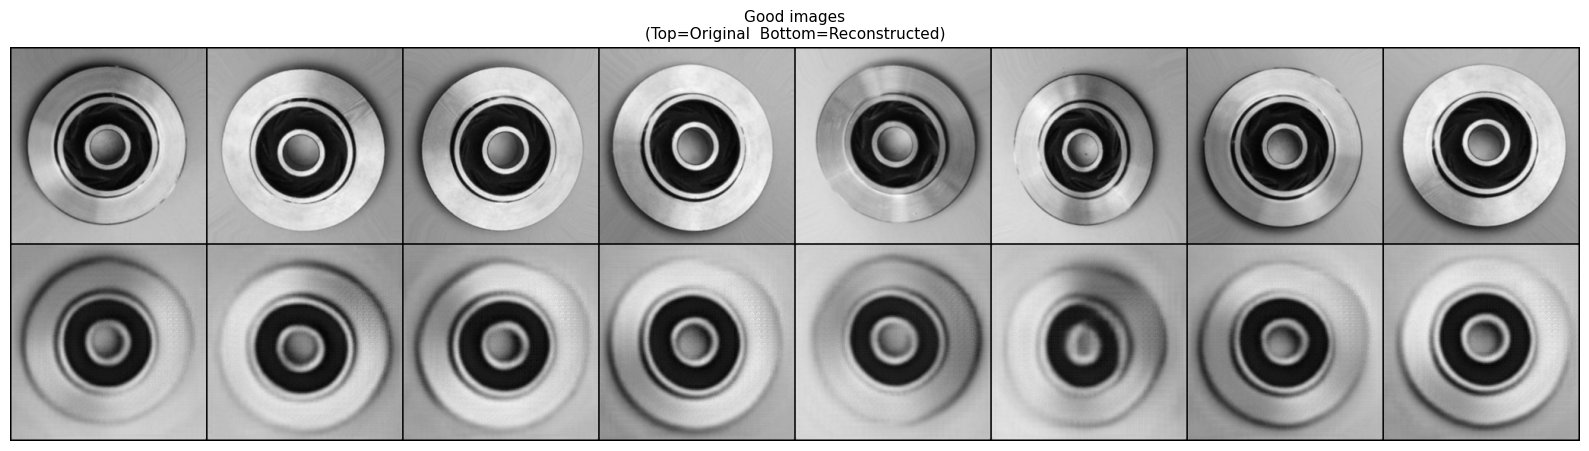


=== Defect images ===
Saved: runs/vae_marble/recon_defect.png


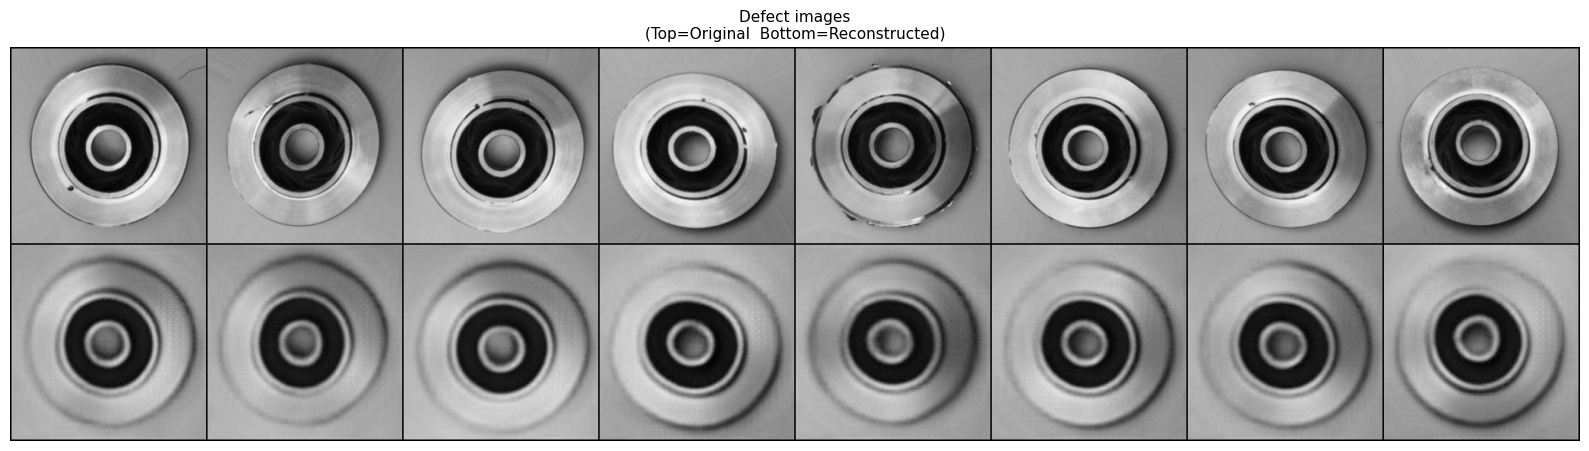

In [ ]:
@torch.no_grad()
def show_reconstructions(model, dataset, device, n=8, title="Reconstruction", save_path=None):
    
    model.eval()
    indices = torch.randperm(len(dataset))[:n].tolist()

    imgs  = torch.stack([dataset[i][0] for i in indices])  # [n, C, H, W]
    imgs  = imgs.to(device)
    x_hat, _, _ = model(imgs)

    
    if CFG.get("normalize", False):
        imgs  = imgs  * 0.5 + 0.5
        x_hat = x_hat * 0.5 + 0.5

    imgs  = imgs.clamp(0, 1).cpu()
    x_hat = x_hat.clamp(0, 1).cpu()

    
    combined = torch.cat([imgs, x_hat], dim=0)  # [2n, C, H, W]
    grid = make_grid(combined, nrow=n, padding=2)

    plt.figure(figsize=(2*n, 5))
    plt.imshow(grid.permute(1,2,0).squeeze(), cmap="gray" if CFG["channels"]==1 else None)
    plt.axis("off")
    plt.title(f"{title}\n(Top=Original  Bottom=Reconstructed)", fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()



print("=== Good images ===")
good_indices = [i for i,(_, lab) in enumerate(test_ds) if lab == 0]
good_subset  = torch.utils.data.Subset(test_ds, good_indices)
show_reconstructions(model, good_subset, device, n=8,
                     title="Good images",
                     save_path=str(out_dir/"recon_good.png"))


print("\n=== Defect images ===")
defect_indices = [i for i,(_, lab) in enumerate(test_ds) if lab == 1]
defect_subset  = torch.utils.data.Subset(test_ds, defect_indices)
show_reconstructions(model, defect_subset, device, n=8,
                     title="Defect images",
                     save_path=str(out_dir/"recon_defect.png"))

## 6) Reconstruction Quality Metrics — MSE / SSIM / PSNR
Quantitative reconstruction metrics for normal vs defect samples.

Computing metrics for good images...
Computing metrics for defect images...

Metric                         Good           Defect
-------------------------------------------------------
N samples                       233              312
MSE (↓)                 0.00801±0.0024      0.00972±0.0036
PSNR dB (↑)               21.15±1.26        20.40±1.51
SSIM (↑)                 0.6578±0.0386       0.6449±0.0357

解讀：
  MSE  Good < Defect → ✅
  PSNR Good > Defect → ✅
  SSIM Good > Defect → ✅


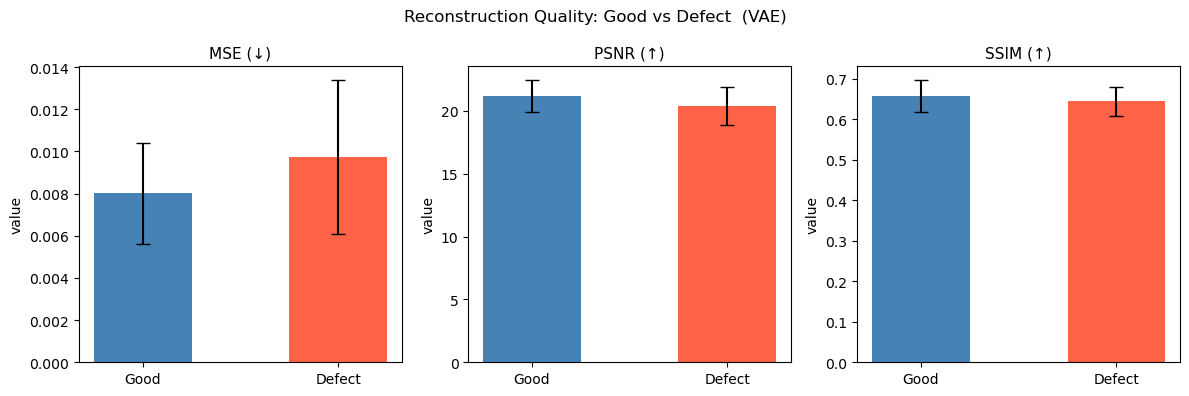

Saved: runs/vae_marble/recon_metrics.png
Metrics saved: runs/vae_marble/recon_metrics.json


In [ ]:
try:
    from skimage.metrics import structural_similarity as ssim_fn
    SKIMAGE_OK = True
except ImportError:
    print("scikit-image not found. Run: pip install scikit-image")
    SKIMAGE_OK = False


@torch.no_grad()
def compute_reconstruction_metrics(model, dataset, device, label_name=""):
    """
    - MSE  : Mean Squared Error
    - PSNR : Peak Signal-to-Noise Ratio
    - SSIM : Structural Similarity Index
    """
    model.eval()
    mse_list  = []
    psnr_list = []
    ssim_list = []

    loader = DataLoader(dataset, batch_size=CFG["batch_size"],
                        shuffle=False, num_workers=CFG["num_workers"])

    for x, _ in loader:
        x     = x.to(device)
        x_hat, _, _ = model(x)

        
        if CFG.get("normalize", False):
            x     = x     * 0.5 + 0.5
            x_hat = x_hat * 0.5 + 0.5
        x     = x.clamp(0, 1).cpu()
        x_hat = x_hat.clamp(0, 1).cpu()

        for i in range(x.size(0)):
            orig = x[i].numpy()      # [C, H, W]
            recon = x_hat[i].numpy()

            # MSE
            mse = float(((orig - recon) ** 2).mean())
            mse_list.append(mse)

            # PSNR（MSE=0 => 100dB）
            psnr = 10 * math.log10(1.0 / mse) if mse > 1e-10 else 100.0
            psnr_list.append(psnr)

            # SSIM
            if SKIMAGE_OK:
                orig_hw  = orig[0]  if orig.shape[0]  == 1 else orig.transpose(1,2,0)
                recon_hw = recon[0] if recon.shape[0] == 1 else recon.transpose(1,2,0)
                s = ssim_fn(orig_hw, recon_hw,
                            data_range=1.0,
                            channel_axis=None if orig.shape[0]==1 else -1)
                ssim_list.append(float(s))

    results = {
        "label":    label_name,
        "n":        len(mse_list),
        "mse_mean": float(np.mean(mse_list)),
        "mse_std":  float(np.std(mse_list)),
        "psnr_mean":float(np.mean(psnr_list)),
        "psnr_std": float(np.std(psnr_list)),
    }
    if SKIMAGE_OK:
        results["ssim_mean"] = float(np.mean(ssim_list))
        results["ssim_std"]  = float(np.std(ssim_list))
    return results



good_indices   = [i for i,(_, lab) in enumerate(test_ds) if lab == 0]
defect_indices = [i for i,(_, lab) in enumerate(test_ds) if lab == 1]

good_subset   = torch.utils.data.Subset(test_ds, good_indices)
defect_subset = torch.utils.data.Subset(test_ds, defect_indices)

print("Computing metrics for good images...")
good_metrics   = compute_reconstruction_metrics(model, good_subset,   device, "good")

print("Computing metrics for defect images...")
defect_metrics = compute_reconstruction_metrics(model, defect_subset, device, "defect")


print()
print("=" * 55)
print(f"{'Metric':<18} {'Good':>16} {'Defect':>16}")
print("-" * 55)
print(f"{'N samples':<18} {good_metrics['n']:>16} {defect_metrics['n']:>16}")
print(f"{'MSE (↓)':<18} {good_metrics['mse_mean']:>12.5f}±{good_metrics['mse_std']:.4f} "
      f"{defect_metrics['mse_mean']:>12.5f}±{defect_metrics['mse_std']:.4f}")
print(f"{'PSNR dB (↑)':<18} {good_metrics['psnr_mean']:>12.2f}±{good_metrics['psnr_std']:.2f} "
      f"{defect_metrics['psnr_mean']:>12.2f}±{defect_metrics['psnr_std']:.2f}")
if SKIMAGE_OK:
    print(f"{'SSIM (↑)':<18} {good_metrics['ssim_mean']:>12.4f}±{good_metrics['ssim_std']:.4f} "
          f"{defect_metrics['ssim_mean']:>12.4f}±{defect_metrics['ssim_std']:.4f}")
print("=" * 55)
print()
print("解讀：")
print(f"  MSE  Good < Defect → {'better' if good_metrics['mse_mean'] < defect_metrics['mse_mean'] else 'worse'}")
print(f"  PSNR Good > Defect → {'better' if good_metrics['psnr_mean'] > defect_metrics['psnr_mean'] else 'worse'}")
if SKIMAGE_OK:
    print(f"  SSIM Good > Defect → {'better' if good_metrics['ssim_mean'] > defect_metrics['ssim_mean'] else 'worse'}")

# Visualization
metrics_names = ["MSE (↓)", "PSNR (↑)"]
good_vals     = [good_metrics["mse_mean"],  good_metrics["psnr_mean"]]
defect_vals   = [defect_metrics["mse_mean"], defect_metrics["psnr_mean"]]
good_errs     = [good_metrics["mse_std"],   good_metrics["psnr_std"]]
defect_errs   = [defect_metrics["mse_std"],  defect_metrics["psnr_std"]]

if SKIMAGE_OK:
    metrics_names.append("SSIM (↑)")
    good_vals.append(good_metrics["ssim_mean"])
    defect_vals.append(defect_metrics["ssim_mean"])
    good_errs.append(good_metrics["ssim_std"])
    defect_errs.append(defect_metrics["ssim_std"])

fig, axes = plt.subplots(1, len(metrics_names), figsize=(4*len(metrics_names), 4))
if len(metrics_names) == 1: axes = [axes]
x = np.arange(2)
for ax, name, gv, dv, ge, de in zip(axes, metrics_names, good_vals, defect_vals, good_errs, defect_errs):
    bars = ax.bar(["Good", "Defect"], [gv, dv], yerr=[ge, de],
                  color=["steelblue","tomato"], capsize=5, width=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("value")
plt.suptitle("Reconstruction Quality: Good vs Defect  (VAE)", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir/"recon_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_dir/"recon_metrics.png")

# Save to JSON
comparison = {"model": "VAE", "good": good_metrics, "defect": defect_metrics,
              "auroc": float(auroc) if 'auroc' in dir() else None}
(out_dir/"recon_metrics.json").write_text(json.dumps(comparison, indent=2), encoding="utf-8")
print("Metrics saved:", out_dir/"recon_metrics.json")